# RNA-seq differential expression analysis in Python

## Goal of this analysis

This tutorial walks through a basic RNA-seq **differential expression** analysis in Python.

RNA-seq measures gene expression by counting sequencing reads that map to genes. Differential expression, often shortened to **DE**, asks whether a gene's expression differs between biological conditions. Here, we are asking whether gene expression differs between prostate cancer tissue and matched normal prostate tissue.

Our main question is:

> Which genes are expressed differently in cancer tissue compared with matched normal tissue?

## Dataset

This notebook analyzes RNA-seq gene count data from six matched prostate samples.

The dataset contains:

- 3 cancer samples
- 3 matched normal samples
- 3 patients, with one cancer sample and one normal sample per patient

Because the samples are matched, each cancer sample should be compared against the normal sample from the same patient. This matters because patients can differ from each other for many reasons unrelated to cancer, such as genetics, age, health history, and technical variation during sample processing.

## Statistical design

The statistical design for this analysis is:

```text
expression ~ patient + condition

## Task 1. Package setup

Run the installation cell once at the start of the notebook session. In Google Colab, packages may need to be installed again when the runtime restarts.

PyDESeq2 is a Python implementation of the core DESeq2 workflow. It uses raw RNA-seq counts and fits a negative binomial model for each gene.

In [ ]:
# Install packages used in this notebook.
# The -q option makes installation output shorter.

!pip install -q pydeseq2 adjustText

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 3.2 MB/s eta 0:00:00


In [ ]:
# pandas stores tables, similar to spreadsheets or data frames.
import pandas as pd

# numpy is used for numerical calculations.
import numpy as np

# matplotlib makes plots.
import matplotlib.pyplot as plt

# PCA is a dimension reduction method used here for sample quality assessment.
from sklearn.decomposition import PCA

# adjustText helps move text labels in plots so they overlap less.
from adjustText import adjust_text

# PyDESeq2 performs the differential expression analysis.
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.preprocessing import deseq2_norm

# Display a reasonable number of rows and columns in notebook tables.
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 20)

## Task 2. Connect to Google Drive

This notebook assumes the six count files are stored in a Google Drive folder named `RNAseqFiles/`.

In Colab, a common location is:

```text
/content/drive/MyDrive/RNAseqFiles/
```

Each input file should have exactly two columns:

1. gene name
2. raw read count for that gene

The files should not have column headers.

In [ ]:
# Run this cell in Google Colab so Python can access files in your Google Drive.
# If you are not using Colab, you can skip this cell and edit count_dir below.

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Folder containing the six count files.
# Keep the final / at the end because we will paste file names onto this folder name.

count_dir = "/content/drive/MyDrive/ColabNotebooks/SCIP2026/UPDATED CURRICULUM/Python Track/Python2026/scip_data/Chapter5/RNAseqFiles"

## Task 3. Input file loading

Here we write down the sample information directly. This is deliberately explicit: each file is matched with its sample name, condition, and patient ID.

`condition` uses:

- `C` for cancer
- `N` for normal

The patient IDs show the matched design. Patient 15 has one cancer sample and one normal sample, patient 19 has one of each, and patient 23 has one of each.

In [ ]:
# This table connects each file to the biological information needed for analysis.
# There is no automatic file searching here. The six file names are written directly.

sample_table = pd.DataFrame({
    "sample": [
        "SRR057638_C_15",
        "SRR057641_C_19",
        "SRR057642_C_23",
        "SRR057656_N_15",
        "SRR057657_N_19",
        "SRR057658_N_23",
    ],
    "file_name": [
        "SRR057638-GCF_000195955.2_ASM19595v2.ReadsPerGene.final",
        "SRR057641-GCF_000195955.2_ASM19595v2.ReadsPerGene.final",
        "SRR057642-GCF_000195955.2_ASM19595v2.ReadsPerGene.final",
        "SRR057656-GCF_000195955.2_ASM19595v2.ReadsPerGene.final",
        "SRR057657-GCF_000195955.2_ASM19595v2.ReadsPerGene.final",
        "SRR057658-GCF_000195955.2_ASM19595v2.ReadsPerGene.final",
    ],
    "condition": ["C", "C", "C", "N", "N", "N"],
    "patient": ["15", "19", "23", "15", "19", "23"],
})

sample_table

,sample,file_name,condition,patient
0,SRR057638_C_15,SRR057638-GCF_000195955.2_ASM19595v2.ReadsPerG...,C,15
1,SRR057641_C_19,SRR057641-GCF_000195955.2_ASM19595v2.ReadsPerG...,C,19
2,SRR057642_C_23,SRR057642-GCF_000195955.2_ASM19595v2.ReadsPerG...,C,23
3,SRR057656_N_15,SRR057656-GCF_000195955.2_ASM19595v2.ReadsPerG...,N,15
4,SRR057657_N_19,SRR057657-GCF_000195955.2_ASM19595v2.ReadsPerG...,N,19
5,SRR057658_N_23,SRR057658-GCF_000195955.2_ASM19595v2.ReadsPerG...,N,23


In [ ]:
# Check the matched design.
# Each patient should have one cancer sample and one normal sample.

pd.crosstab(sample_table["patient"], sample_table["condition"])

condition,C,N
patient,,
15,1,1
19,1,1
23,1,1


Now we read each two-column count file.

The important line is:

```python
pd.read_csv(file_path, sep="\t", header=None, names=["gene", sample_name])
```

This tells Python:

- the file is tab-separated
- there is no header row
- column 1 should be called `gene`
- column 2 should be named after the sample

After reading all six files, we merge them into one count table.

In [ ]:
import os

first_sample = sample_table.loc[0, "sample"]
first_file = os.path.join(count_dir, sample_table.loc[0, "file_name"])

count_table = pd.read_csv(
    first_file,
    sep="\t",
    header=None,
    names=["gene", first_sample]
)

for i in range(1, len(sample_table)):
    sample_name = sample_table.loc[i, "sample"]
    file_path = os.path.join(count_dir, sample_table.loc[i, "file_name"])

    one_sample_counts = pd.read_csv(
        file_path,
        sep="\t",
        header=None,
        names=["gene", sample_name]
    )

    count_table = count_table.merge(one_sample_counts, on="gene")

count_table = count_table.set_index("gene").astype(int)

In [ ]:
# Check the size of the count table.
# Rows are genes and columns are samples.

count_table.shape

(48897, 6)

In [ ]:
# PyDESeq2 expects samples as rows and genes as columns.
# Our table currently has genes as rows and samples as columns, so we transpose it with .T.

counts_for_analysis = count_table.T

counts_for_analysis.head()

gene,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,MIR1302-2,FAM138A,OR4F5,LOC124903816,LOC124900384,LOC729737,LOC124903814,DDX11L17,LOC100996442,MIR6859-2,LOC127239154,LOC124903815,LOC124900618,LOC112268260,OR4F29,LOC100132287,LOC124904706,LOC105378947,LOC101928626,MIR12136,OR4F16,...,TRNN,TRNC,TRNY,COX1,TRNS1,TRND,COX2,TRNK,ATP8,ATP6,COX3,TRNG,ND3,TRNR,ND4L,ND4,TRNH,TRNS2,TRNL2,ND5,ND6,TRNE,CYTB,TRNT,TRNP
SRR057638_C_15,0,37,3,0,0,0,0,0,8,20,0,0,40,3,3,0,0,0,0,2,0,1,0,4,1,...,0,8,47,127144,3,0,70565,0,2184,46859,69433,0,11797,0,12377,146622,0,2,0,51781,14461,4,65338,2,226
SRR057641_C_19,0,21,3,0,0,0,0,0,3,120,0,0,41,0,5,1,1,0,0,2,0,0,0,3,1,...,0,30,154,133582,1,0,67648,0,2570,49191,76883,0,16569,0,10923,141627,2,2,1,72295,23509,11,88742,2,317
SRR057642_C_23,0,37,6,0,0,0,0,0,0,40,0,3,24,0,6,0,0,0,0,2,0,0,0,4,2,...,0,17,89,130098,0,0,76283,0,2797,47720,49659,0,17252,0,10654,119908,1,2,0,55732,19543,7,69867,2,276
SRR057656_N_15,0,21,17,0,0,0,0,0,2,53,0,0,38,0,0,0,0,0,0,8,0,1,0,0,0,...,0,27,89,66653,1,0,42969,0,2316,30530,35171,0,7951,0,8368,88058,1,2,4,50174,14388,6,46126,0,100
SRR057657_N_19,0,11,6,0,0,0,0,0,1,46,0,0,36,1,3,0,0,0,0,0,0,0,0,0,0,...,0,23,55,65092,0,0,34417,0,2889,24754,35823,0,7101,0,8281,75102,0,2,1,36880,12176,4,39245,0,128


In [ ]:
# The metadata table should have sample names as its index.
# This helps PyDESeq2 line up the sample labels with the count table.

metadata = sample_table[["sample", "condition", "patient"]].copy()
metadata = metadata.set_index("sample")

# Set the reference level for condition.
# N is listed before C so normal is treated as the reference group.
metadata["condition"] = pd.Categorical(metadata["condition"], categories=["N", "C"])
metadata["patient"] = pd.Categorical(metadata["patient"])

metadata

,condition,patient
sample,,
SRR057638_C_15,C,15
SRR057641_C_19,C,19
SRR057642_C_23,C,23
SRR057656_N_15,N,15
SRR057657_N_19,N,19
SRR057658_N_23,N,23


## Task 4. Quality assessment

Before running differential expression, we should check whether the samples behave in a reasonable way.

We will do two checks:

1. library size, which is the total number of reads counted for each sample
2. PCA, which shows the largest expression-pattern differences among samples

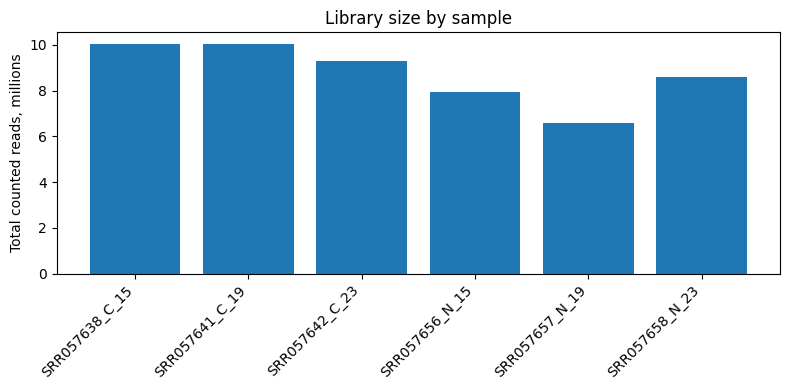

,0
SRR057638_C_15,10.032232
SRR057641_C_19,10.050424
SRR057642_C_23,9.312760
SRR057656_N_15,7.936731
SRR057657_N_19,6.577290
SRR057658_N_23,8.618629


In [ ]:
# Library size is the total number of counted reads in each sample.
# Large differences in library size are common in sequencing data, but extreme values can suggest a problem.

library_sizes = counts_for_analysis.sum(axis=1)

library_sizes_millions = library_sizes / 1_000_000

plt.figure(figsize=(8, 4))
plt.bar(library_sizes_millions.index, library_sizes_millions.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total counted reads, millions")
plt.title("Library size by sample")
plt.tight_layout()
plt.show()

library_sizes_millions

### PCA from raw count data

You may have seen PCA before using precomputed PCA eigenvectors or precomputed PC scores. Here, we are starting earlier in the process.

Our input is not already a PCA result. Our input is a large gene expression matrix:

- rows are samples
- columns are genes
- values are counts

To run PCA ourselves, we need to make the counts more comparable across samples. Raw counts are affected by sequencing depth, so we first convert counts to counts per million, or CPM. Then we use `log2(CPM + 1)` so that a few very highly expressed genes do not dominate the plot.

After that, PCA finds combinations of genes that explain the largest sources of variation among samples. Each point in the PCA plot is a sample. The PC1 and PC2 coordinates are calculated from all genes that pass the simple count filter below.

In [ ]:
# Use a simple filter before PCA so genes with almost no counts do not add noise.
# This does not choose genes based on condition or significance.

keep_for_pca = counts_for_analysis.sum(axis=0) > 10
counts_for_pca = counts_for_analysis.loc[:, keep_for_pca]

# Convert raw counts to counts per million to adjust for different library sizes.
counts_per_million = counts_for_pca.div(library_sizes, axis=0) * 1_000_000

# Log-transform the CPM values.
# Adding 1 avoids taking log2(0), which is undefined.
log_cpm = np.log2(counts_per_million + 1)

log_cpm.shape

(6, 21181)

In [ ]:
# Fit PCA using the log2(CPM + 1) matrix.
# Each row is a sample. Each column is a gene.

pca = PCA(n_components=2)
pca_coordinates = pca.fit_transform(log_cpm)

pca_df = pd.DataFrame(
    pca_coordinates,
    columns=["PC1", "PC2"],
    index=log_cpm.index
)

# Add sample information so we can color and label the plot.
pca_df = pca_df.join(metadata)

# Percent variance tells us how much of the total expression variation is represented by each PC.
percent_variance = pca.explained_variance_ratio_ * 100

pca_df

,PC1,PC2,condition,patient
SRR057638_C_15,31.238269,-35.554554,C,15
SRR057641_C_19,42.402113,2.370060,C,19
SRR057642_C_23,39.746604,32.864063,C,23
SRR057656_N_15,-40.313568,-58.681140,N,15
SRR057657_N_19,-6.892494,20.966395,N,19
SRR057658_N_23,-66.180924,38.035177,N,23


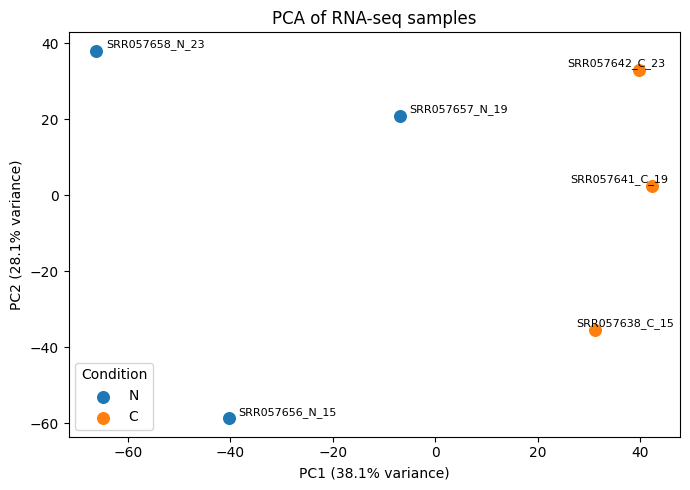

In [ ]:
# Plot the PCA result.
# Points that are close together have more similar overall expression profiles.

plt.figure(figsize=(7, 5))
texts = []

for condition in ["N", "C"]:
    subset = pca_df[pca_df["condition"] == condition]
    plt.scatter(subset["PC1"], subset["PC2"], label=condition, s=70)

for sample_name, row in pca_df.iterrows():
    texts.append(plt.text(row["PC1"], row["PC2"], sample_name, fontsize=8))

adjust_text(texts)

plt.xlabel(f"PC1 ({percent_variance[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({percent_variance[1]:.1f}% variance)")
plt.title("PCA of RNA-seq samples")
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

PCA interpretation:

- Samples close together have more similar overall gene expression profiles.
- If cancer and normal samples separate, condition is a major source of variation.
- If matched patient pairs are close together or show a paired pattern, patient identity is also important.
- A sample far away from all others should be checked before making biological conclusions.

PCA is not the differential expression test. It is a quality assessment and exploratory visualization step.

## Task 5. Differential expression setup

Differential expression testing should use raw integer counts, not CPM, TPM, FPKM, normalized counts, or log-transformed values.

The model will test cancer versus normal while accounting for patient:

```text
counts ~ patient + condition
```

This is important because the samples are matched. Patient-to-patient expression differences can be large, even when the condition effect is the main biological question.

In [ ]:
# Filter low-count genes before DE testing.
# Genes with almost no reads provide little information and make multiple-testing correction harder.
# This filter uses only total count, not cancer/normal differences.

keep_for_de = counts_for_analysis.sum(axis=0) > 10
counts_filtered = counts_for_analysis.loc[:, keep_for_de].copy()

counts_for_analysis.shape, counts_filtered.shape

((6, 48897), (6, 21181))

In [ ]:
# Build the PyDESeq2 dataset object.
# counts is samples x genes.
# metadata is samples x sample variables.
# The design tells the model to account for patient before testing condition.

dds = DeseqDataSet(
    counts=counts_filtered,
    metadata=metadata,
    design="~ patient + condition",
    ref_level=["condition", "N"],
    refit_cooks=True,
    quiet=False
)

dds

/tmp/ipykernel_49109/271235021.py:6: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(


AnnData object with n_obs × n_vars = 6 × 21181
    obs: 'condition', 'patient'
    obsm: 'design_matrix'

In [ ]:
# Run the DESeq2-like workflow.
# This estimates size factors, gene-wise dispersion, fitted dispersions, and model coefficients.

dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 23.68 seconds.

Fitting dispersion trend curve...
... done in 1.00 seconds.

/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 25.26 seconds.

Fitting LFCs...
... done in 21.05 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



## Task 6. Differential expression results

The contrast below means:

```text
condition C compared with condition N
```

So the log2 fold change is interpreted as cancer relative to normal.

- positive log2 fold change means higher expression in cancer
- negative log2 fold change means lower expression in cancer

In [ ]:
# Extract cancer-vs-normal results.

stat_res = DeseqStats(
    dds,
    contrast=["condition", "C", "N"],
    alpha=0.05,
    cooks_filter=True,
    independent_filter=True
)

stat_res.summary()

# Convert the PyDESeq2 results table into a regular pandas DataFrame.
res_df = stat_res.results_df.copy()
res_df.index.name = "gene"
res_df = res_df.reset_index()

# Remove genes without adjusted p-values.
res_df = res_df.dropna(subset=["padj"])

res_df.head()

Running Wald tests...
... done in 6.02 seconds.



Log2 fold change & Wald test p-value: condition C vs N
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene                                                                       
WASH7P           26.894877        0.026096  0.576379  0.045276  0.963888   
MIR6859-1         9.505900       -2.184473  0.963973 -2.266113  0.023444   
LOC124900384      2.736564       -0.211269  1.773141 -0.119149  0.905157   
LOC729737        66.554137       -1.074043  0.520937 -2.061753  0.039231   
LOC100996442     36.976920       -0.645300  0.498113 -1.295489  0.195151   
...                    ...             ...       ...       ...       ...   
ND5           50395.643858       -0.021325  0.233282 -0.091412  0.927165   
ND6           15895.908339       -0.011996  0.237915 -0.050420  0.959788   
TRNE              5.831029        0.062133  1.141999  0.054407  0.956611   
CYTB          57529.638758        0.221259  0.218135  1.014321  0.310430   
TRNP            189.020090       

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,WASH7P,26.894877,0.026096,0.576379,0.045276,0.963888,0.986482
3,LOC729737,66.554137,-1.074043,0.520937,-2.061753,0.039231,0.174657
4,LOC100996442,36.976920,-0.645300,0.498113,-1.295489,0.195151,0.447537
8,LOC100288069,76.175930,0.139540,0.416650,0.334908,0.737694,0.878869
12,LINC00115,28.693904,0.096077,0.560421,0.171437,0.863880,0.945246


In [20]:
# Sort genes by adjusted p-value.
# Small adjusted p-values have stronger evidence for differential expression.

res_df_sorted = res_df.sort_values("padj")
res_df_sorted.head(10)

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
8354,FLNC,8760.998397,-2.291193,0.232056,-9.873427,5.427767e-23,8.153049e-19
11439,GLYATL1,497.034698,2.618495,0.273034,9.590363,8.777550e-22,6.592379e-18
1606,F5,250.257573,2.951579,0.321400,9.183519,4.172297e-20,2.089069e-16
10656,SNCG,407.171249,-2.717411,0.300001,-9.058001,1.328635e-19,4.989356e-16
13592,LOC124903192,284.757499,3.237140,0.363010,8.917509,4.768940e-19,1.432685e-15
9565,GCNT1,812.132669,2.705827,0.320037,8.454738,2.797142e-17,7.002646e-14
14899,ANPEP,4372.288326,-2.428493,0.289069,-8.401095,4.423357e-17,9.491891e-14
2102,CHRM3,208.582192,3.695422,0.446906,8.268907,1.351932e-16,2.538421e-13
20806,FLNA,75871.565482,-1.961863,0.243050,-8.071866,6.923193e-16,1.155481e-12
5177,PRDM8,805.927415,-2.104227,0.261490,-8.047062,8.480537e-16,1.158056e-12


Important result columns:

- `baseMean`: average normalized expression across all samples
- `log2FoldChange`: estimated expression difference on a log2 scale
- `lfcSE`: standard error of the log2 fold change
- `stat`: test statistic
- `pvalue`: raw p-value for one gene
- `padj`: adjusted p-value after correcting for many tests

The adjusted p-value is important because thousands of genes are tested. Without correction, many genes could look significant just by chance.

In [21]:
# Define differentially expressed genes using teaching thresholds.
# padj < 0.05 controls the false discovery rate.
# abs(log2FoldChange) > 1 means at least a two-fold difference.

padj_cutoff = 0.05
log2fc_cutoff = 1

sig_de_genes = res_df[
    (res_df["padj"] < padj_cutoff) &
    (res_df["log2FoldChange"].abs() > log2fc_cutoff)
].copy()

sig_de_genes = sig_de_genes.sort_values("padj")

print("Number of DE genes:", sig_de_genes.shape[0])
sig_de_genes.head(10)

Number of DE genes: 1073


,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
8354,FLNC,8760.998397,-2.291193,0.232056,-9.873427,5.427767e-23,8.153049e-19
11439,GLYATL1,497.034698,2.618495,0.273034,9.590363,8.777550e-22,6.592379e-18
1606,F5,250.257573,2.951579,0.321400,9.183519,4.172297e-20,2.089069e-16
10656,SNCG,407.171249,-2.717411,0.300001,-9.058001,1.328635e-19,4.989356e-16
13592,LOC124903192,284.757499,3.237140,0.363010,8.917509,4.768940e-19,1.432685e-15
9565,GCNT1,812.132669,2.705827,0.320037,8.454738,2.797142e-17,7.002646e-14
14899,ANPEP,4372.288326,-2.428493,0.289069,-8.401095,4.423357e-17,9.491891e-14
2102,CHRM3,208.582192,3.695422,0.446906,8.268907,1.351932e-16,2.538421e-13
20806,FLNA,75871.565482,-1.961863,0.243050,-8.071866,6.923193e-16,1.155481e-12
5177,PRDM8,805.927415,-2.104227,0.261490,-8.047062,8.480537e-16,1.158056e-12


## Task 7. DE result visualizations

The next plots help summarize the DE results. These plots do not replace the statistical table, but they make broad patterns easier to see.

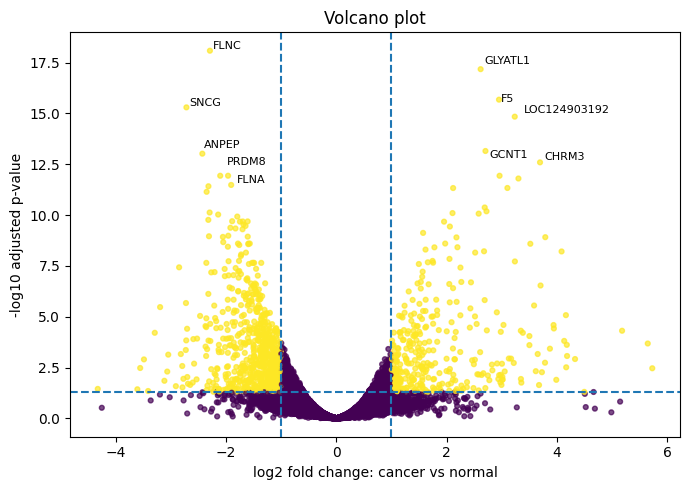

In [22]:
# Volcano plot.
# x-axis: size and direction of expression change
# y-axis: statistical evidence after multiple-testing correction

plot_df = res_df.copy()
plot_df["minus_log10_padj"] = -np.log10(plot_df["padj"])
plot_df["significant"] = (
    (plot_df["padj"] < padj_cutoff) &
    (plot_df["log2FoldChange"].abs() > log2fc_cutoff)
)

plt.figure(figsize=(7, 5))
plt.scatter(
    plot_df["log2FoldChange"],
    plot_df["minus_log10_padj"],
    c=plot_df["significant"],
    alpha=0.7,
    s=12
)

plt.axvline(-log2fc_cutoff, linestyle="--")
plt.axvline(log2fc_cutoff, linestyle="--")
plt.axhline(-np.log10(padj_cutoff), linestyle="--")

# Label the 10 most significant genes.
texts = []
for _, row in plot_df.sort_values("padj").head(10).iterrows():
    texts.append(plt.text(row["log2FoldChange"], row["minus_log10_padj"], row["gene"], fontsize=8))

adjust_text(texts)

plt.xlabel("log2 fold change: cancer vs normal")
plt.ylabel("-log10 adjusted p-value")
plt.title("Volcano plot")
plt.tight_layout()
plt.show()

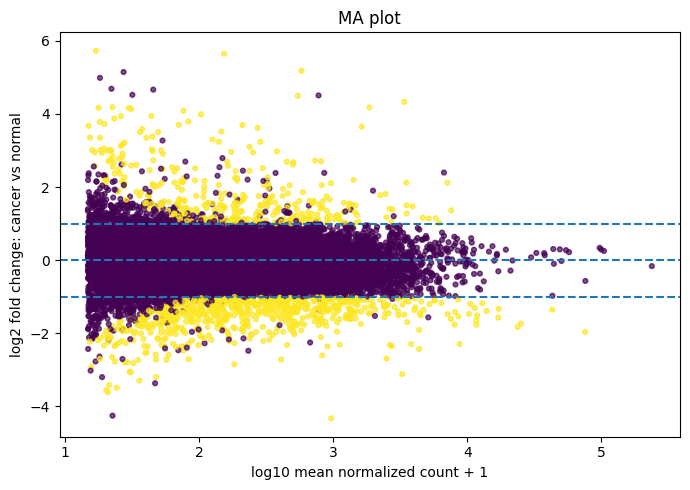

In [23]:
# MA plot.
# x-axis: average normalized expression
# y-axis: expression change between groups
# This helps show whether large fold changes mostly occur in low-count genes.

plt.figure(figsize=(7, 5))
plt.scatter(
    np.log10(plot_df["baseMean"] + 1),
    plot_df["log2FoldChange"],
    c=plot_df["significant"],
    alpha=0.7,
    s=12
)

plt.axhline(0, linestyle="--")
plt.axhline(-log2fc_cutoff, linestyle="--")
plt.axhline(log2fc_cutoff, linestyle="--")

plt.xlabel("log10 mean normalized count + 1")
plt.ylabel("log2 fold change: cancer vs normal")
plt.title("MA plot")
plt.tight_layout()
plt.show()

## Task 8. Heatmap of top DE genes

A heatmap shows expression patterns for selected genes across samples.

Here we use normalized counts from the DESeq2 size-factor method. Then we use `log2(normalized count + 1)` for plotting. Finally, each gene is row-scaled so the heatmap shows whether a gene is high or low relative to its own average expression across samples.

Row scaling means colors should be compared within a gene, not between different genes.

In [24]:
# Get DESeq2-style normalized counts for plotting.
# These are for visualization, not for re-running DE tests.

normalized_counts, size_factors = deseq2_norm(counts_filtered)

normalized_counts = pd.DataFrame(
    normalized_counts,
    index=counts_filtered.index,
    columns=counts_filtered.columns
)

normalized_counts.head()

gene,WASH7P,MIR6859-1,LOC124900384,LOC729737,LOC100996442,LOC127239154,LOC100132287,MIR12136,LOC100288069,LINC01409,LOC124903817,FAM87B,LINC00115,LINC01128,LOC284600,LINC02593,LOC107985728,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,...,RPS9_7,LAIR1_2,NLRP2_7,TRNF,RNR1,RNR2,TRNL1,ND1,ND2,TRNC,TRNY,COX1,COX2,ATP8,ATP6,COX3,ND3,ND4L,ND4,TRNS2,ND5,ND6,TRNE,CYTB,TRNP
SRR057638_C_15,32.771542,2.657152,7.085739,17.714347,35.428694,2.657152,1.771435,3.542869,109.828953,7.971456,5.314304,10.628608,23.914369,290.515295,88.571736,19.485782,98.314627,76.171693,829.031451,180.686342,151.457669,13.285760,167.400581,169.172016,3140.753765,...,0.000000,4.428587,1.771435,5.314304,9312.432342,49669.258217,3.542869,32989.428859,27002.865211,7.085739,41.628716,112613.648254,62500.645639,1934.406718,41503.829859,61498.013585,10448.807718,10962.523788,129865.651028,1.771435,45863.330714,12808.358770,3.542869,57871.000988,200.172124
SRR057641_C_19,16.678021,2.382574,2.382574,95.302976,32.561850,3.970957,1.588383,2.382574,71.477232,15.089638,13.501255,11.912872,26.208318,282.732163,37.326999,18.266404,64.329509,64.329509,852.167447,172.339549,100.068125,7.147723,171.545357,88.155253,1927.502696,...,11.118681,0.794191,29.385084,7.147723,7644.092894,47944.544823,4.765149,39626.183371,28601.217391,23.825744,122.305486,106089.684879,53725.464529,2041.072077,39067.072576,61059.822750,13158.958458,8674.953421,112478.955252,1.588383,57416.072288,18670.647257,8.736106,70478.139387,251.758696
SRR057642_C_23,30.498954,4.945776,0.000000,32.971842,19.783105,4.945776,1.648592,3.297184,56.052132,16.485921,11.540145,5.770072,39.566211,412.148029,121.171521,24.728882,101.388415,121.995817,703.948834,182.993725,103.037007,8.242961,198.655350,182.993725,1884.340791,...,0.000000,3.297184,0.000000,3.297184,7716.235407,47301.405044,1.648592,32666.852814,37001.001492,14.013033,73.362349,107239.268671,62879.776261,2305.556077,39335.407931,40933.717989,14220.755608,8782.050212,98839.691831,1.648592,45939.667955,16109.217879,5.770072,57591.092747,227.505712
SRR057656_N_15,26.807517,21.701323,2.553097,67.657066,48.508840,0.000000,10.212387,0.000000,90.634937,7.659290,7.659290,14.042033,26.807517,560.404753,56.168130,93.188034,319.137103,85.528744,1164.212151,274.457908,123.825196,39.573001,298.712328,128.931390,4328.775663,...,0.000000,3.829645,17.871678,15.318581,4771.737961,33339.614857,7.659290,30578.440643,28761.912254,34.466807,113.612809,85085.781255,54852.008683,2956.486120,38973.022996,44897.484172,10149.836418,10682.157105,112410.299998,2.553097,64049.539986,18366.978541,7.659290,58882.072018,127.654841
SRR057657_N_19,14.082227,7.681215,1.280202,58.889314,46.087289,3.840607,0.000000,0.000000,39.686277,10.241620,6.401012,1.280202,30.724860,321.330823,56.328909,51.208099,192.030372,170.266930,803.967158,229.156244,92.174579,15.362430,245.798876,136.981665,2949.586516,...,7.681215,2.560405,14.082227,14.082227,5020.954130,39329.100418,2.560405,31377.762809,26514.273584,29.444657,70.411136,83330.939892,44060.728788,3698.504968,31690.132214,45860.693476,9090.717817,10601.356745,96145.766727,2.560405,47213.867499,15587.745408,5.120810,50241.546366,163.865918


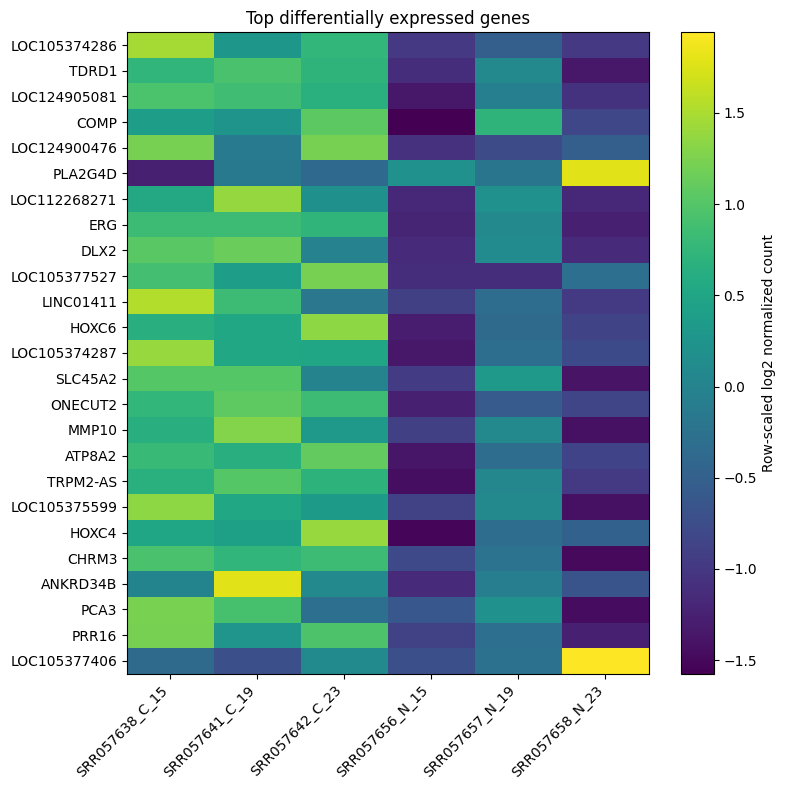

In [25]:
# Select up to 25 significant genes with the largest absolute log2 fold changes.

top_genes = (
    sig_de_genes
    .sort_values("log2FoldChange", key=lambda x: x.abs(), ascending=False)
    .head(25)["gene"]
    .tolist()
)

# Make the heatmap only if there are at least 2 genes to plot.
if len(top_genes) >= 2:
    heatmap_data = np.log2(normalized_counts[top_genes] + 1)

    # Transpose so genes are rows and samples are columns.
    heatmap_data = heatmap_data.T

    # Row-scale each gene.
    # For each gene: subtract that gene's mean and divide by that gene's standard deviation.
    heatmap_scaled = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0)
    heatmap_scaled = heatmap_scaled.div(heatmap_data.std(axis=1), axis=0)

    plt.figure(figsize=(8, 8))
    plt.imshow(heatmap_scaled, aspect="auto")
    plt.colorbar(label="Row-scaled log2 normalized count")
    plt.xticks(range(len(heatmap_scaled.columns)), heatmap_scaled.columns, rotation=45, ha="right")
    plt.yticks(range(len(heatmap_scaled.index)), heatmap_scaled.index)
    plt.title("Top differentially expressed genes")
    plt.tight_layout()
    plt.show()
else:
    print("Fewer than 2 significant DE genes were found with the current thresholds.")

## Task 9. Plot one gene of interest

Single-gene plots are useful when discussing a specific gene. Because this is a matched design, it is helpful to connect the cancer and normal samples from the same patient.

In [26]:
# Choose one gene to inspect.
# Change this gene name to explore another result.

gene_of_interest = "FLNA"

# Create a small table for this one gene.
gene_plot_df = metadata.copy()
gene_plot_df["normalized_count"] = normalized_counts[gene_of_interest]
gene_plot_df["condition_x"] = gene_plot_df["condition"].map({"N": 0, "C": 1}).astype(int)

gene_plot_df

,condition,patient,normalized_count,condition_x
sample,,,,
SRR057638_C_15,C,15,29512.988214,1
SRR057641_C_19,C,19,27166.113406,1
SRR057642_C_23,C,23,32974.315244,1
SRR057656_N_15,N,15,79319.612082,0
SRR057657_N_19,N,19,114447.541395,0
SRR057658_N_23,N,23,171808.822553,0


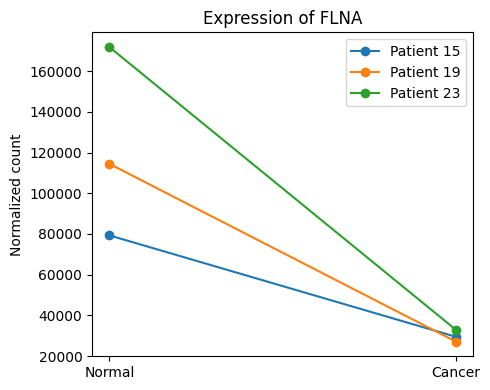

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
20806,FLNA,75871.565482,-1.961863,0.24305,-8.071866,6.923193e-16,1.155481e-12


In [27]:
# Plot the gene for each patient.
# Lines connect matched normal and cancer samples from the same patient.

plt.figure(figsize=(5, 4))

for patient_id, patient_df in gene_plot_df.groupby("patient"):
    patient_df = patient_df.sort_values("condition_x")
    plt.plot(
        patient_df["condition_x"],
        patient_df["normalized_count"],
        marker="o",
        label=f"Patient {patient_id}"
    )

plt.xticks([0, 1], ["Normal", "Cancer"])
plt.ylabel("Normalized count")
plt.title(f"Expression of {gene_of_interest}")
plt.legend()
plt.tight_layout()
plt.show()

res_df[res_df["gene"] == gene_of_interest]

## Task 10. Export results

The result tables can be saved as CSV files. These files will be written to the same Google Drive folder as the input files.

In [28]:
# Save the full result table and the significant DE gene table.

res_df_sorted.to_csv(count_dir + "DE_results_all_genes.csv", index=False)
sig_de_genes.to_csv(count_dir + "DE_results_significant_genes.csv", index=False)

print("Saved:")
print(count_dir + "DE_results_all_genes.csv")
print(count_dir + "DE_results_significant_genes.csv")

Saved:
/content/drive/MyDrive/ColabNotebooks/SCIP2026/UPDATED CURRICULUM/Python Track/Python2026/scip_data/Chapter5/RNAseqFilesDE_results_all_genes.csv
/content/drive/MyDrive/ColabNotebooks/SCIP2026/UPDATED CURRICULUM/Python Track/Python2026/scip_data/Chapter5/RNAseqFilesDE_results_significant_genes.csv


## Summary

In this notebook, you:

1. loaded six two-column RNA-seq count files
2. built a sample metadata table
3. checked library sizes
4. performed PCA from the gene expression matrix
5. fit a matched-patient differential expression model
6. extracted cancer-versus-normal DE results
7. made volcano, MA, heatmap, and single-gene plots
8. exported result tables

For interpretation, report both statistical evidence and effect size. A useful DE result usually includes the gene name, log2 fold change, adjusted p-value, and the biological direction of the change.